# Task 01 - 510300.SH 量化研究

## 研究问题和学习目标

**研究标的**：沪深300ETF（Tushare代码：`510300.SH`）

**研究问题**：
1. 沪深300ETF 近 5 年的价格走势和成交量有何特征？
2. 移动均线（MA5/MA20/MA60）对价格趋势有何指示作用？
3. 日收益率的分布是否符合正态分布？波动率有何变化？

**学习目标**：
- 掌握 Tushare Pro API 的数据获取方法
- 理解 K 线、复权、技术指标的基本概念
- 实践数据清洗、可视化、统计分析的完整流程
- 建立量化分析的严谨思维（数据安全、缓存机制、可复现性）

---

## 量化交易的优势与限制

### 优势

| 优势 | 说明 |
|------|------|
| **纪律性** | 严格执行预设策略，避免情绪化交易 |
| **速度** | 毫秒级响应，捕捉短线机会 |
| **数据处理能力** | 同时处理海量数据，发现人工难以识别的模式 |
| **回测验证** | 基于历史数据验证策略有效性 |
| **多样性** | 同时监控多个标的，分散风险 |

### 限制

| 限制 | 说明 |
|------|------|
| **过度拟合** | 策略在历史数据上表现优异，但未来失效 |
| **黑天鹅事件** | 极端行情下，模型可能失效 |
| **数据质量依赖** | 垃圾进，垃圾出（Garbage In, Garbage Out）|
| **技术限制** | 网络延迟、API 限流、系统故障 |
| **监管风险** | 算法交易可能受到监管政策影响 |

> ⚠️ **重要提醒**：量化分析是辅助决策工具，不构成投资建议。

---

## K线、基本面、技术面和复权的简明解释

### 1. K线（Candlestick Chart）

K线记录一段时间内的**开盘价、收盘价、最高价、最低价**。

- **阳线**（红/绿）：收盘价 > 开盘价，表示上涨
- **阴线**（绿/红）：收盘价 < 开盘价，表示下跌
- **上影线**：最高价与实体之间的线，表示上方压力
- **下影线**：最低价与实体之间的线，表示下方支撑

**示例**：
```
  最高价
    │
    │ 上影线
    │
    ├─── 实体（开盘/收盘）
    │
    │ 下影线
    │
  最低价
```

### 2. 基本面分析（Fundamental Analysis）

研究标的**内在价值**，关注：
- 宏观经济指标（GDP、CPI、利率）
- 行业发展趋势
- 公司财务状况（营收、利润、ROE）
- 估值指标（PE、PB、股息率）

> 对于 ETF（如 510300.SH），基本面分析关注**跟踪误差、流动性、管理费率**等。

### 3. 技术面分析（Technical Analysis）

基于**历史价格和成交量数据**，使用图表和技术指标预测未来走势。

**核心假设**：
1. 市场行为包容一切（价格反映所有信息）
2. 价格呈趋势变动
3. 历史会重演

**常用指标**：
- 移动均线（MA）：平滑价格波动，识别趋势
- RSI（相对强弱指数）：衡量超买/超卖
- MACD：趋势跟踪指标
- 布林带：衡量波动率

### 4. 复权（Adjustment）

由于**分红、送股、配股**等事件，股票价格会出现跳空缺口。复权是为了**消除这些缺口，使价格走势连续**。

| 复权类型 | 说明 | 用途 |
|----------|------|------|
| **前复权（qfq）** | 保持当前价格不变，向前调整历史价格 | 技术分析、图表绘制 |
| **后复权（hfq）** | 保持历史价格不变，向后调整当前价格 | 长期投资回报计算 |

> **示例**：某股票除权前收盘 10 元，除权后开盘 9 元（分红 1 元）。  
> - 前复权：将除权前的价格调整为 9 元，使图表连续。  
> - 后复权：将除权后的价格调整为 10 元，计算累计回报。

---

## 数据源、安全、时间范围和复权说明

### 数据源

- **数据提供商**：Tushare Pro API
- **接口**：`pro.fund_daily()`（未复权）、`ts.pro_bar(adj='qfq')`（前复权）
- **数据频率**：日线
- **复权口径**：前复权（qfq）

### 数据安全

| 安全措施 | 说明 |
|----------|------|
| Token 管理 | 从环境变量 `TUSHARE_TOKEN` 读取，不硬编码 |
| 配置文件 | 使用 `.env` 文件（已加入 `.gitignore`）|
| 禁止行为 | 不打印、不保存 Token 值到任何提交文件 |
| 访问控制 | Token 仅用于 Tushare API 调用 |

### 时间范围

| 优先级 | 时间范围 | 条件 |
|--------|----------|------|
| 1 | 最近 5 年 | Token 权限允许 |
| 2 | 最近 1 年 | 权限不足时退到 1 年 |
| 3 | 报错 | 无数据且无缓存 |

**本次实际范围**：2021-06-21 至 2026-06-18（共 1211 个交易日）

### 复权说明

- **未复权数据**：`data/raw/510300_SH_daily_raw.csv`（原始响应，不修改字段值）
- **前复权数据**：`data/processed/510300_SH_daily_qfq.csv`（使用 Tushare 官方接口）
- **当前状态**：⚠️ 前复权数据获取失败（Tushare 免费账号权限不足），使用未复权数据进行初步分析

---

## 数据获取/缓存状态

本 Notebook 使用**智能缓存机制**：

1. **优先尝试实时 API**：获取最新数据
2. **API 失败时回退缓存**：读取本地缓存，显著标记缓存状态
3. **无缓存时停止**：清楚报告原因，禁止使用示例数据冒充真实数据

**缓存元数据**（如有）保存在：`data/raw/510300_SH_daily_raw_meta.json`

---

In [1]:
# 自动切换工作目录到项目根目录
import os
current_dir = os.getcwd()
# 如果当前在 notebooks/ 目录，则切换到项目根目录
if os.path.basename(current_dir) == 'notebooks':
    os.chdir('..')
    print(f'工作目录已切换至项目根目录：{os.getcwd()}')
else:
    print(f'工作目录：{os.getcwd()}')

# 检查数据获取/缓存状态
import os
import json
import pandas as pd
from datetime import datetime

print('=' * 70)
print('数据获取/缓存状态检查')
print('=' * 70)

# 检查缓存元数据
meta_file = 'data/raw/510300_SH_daily_raw_meta.json'

if os.path.exists(meta_file):
    with open(meta_file, 'r', encoding='utf-8') as f:
        meta = json.load(f)
    
    print(f'\n【缓存状态】')
    print(f'  数据来源：{meta["data_source"]}')
    print(f'  获取时间：{meta["fetch_time"]}')
    print(f'  时间范围：{meta["start_date"]} 至 {meta["end_date"]}')
    print(f'  记录数：{meta["record_count"]}')
    print(f'  复权口径：{meta["adj"]}')
    print(f'  缓存类型：{meta["cache_type"]}')
    
    # 检查缓存年龄
    fetch_time = datetime.strptime(meta['fetch_time'], '%Y-%m-%d %H:%M:%S')
    cache_age = (datetime.now() - fetch_time).days
    
    if cache_age > 7:
        print(f'\n⚠️ 缓存已 {cache_age} 天未更新，建议重新获取')
    else:
        print(f'\n✓ 缓存较新（{cache_age} 天前更新）')
        
else:
    print('\n⚠️ 未找到缓存元数据文件')
    print('  可能是首次获取数据，或元数据文件丢失')

print('\n' + '=' * 70)

工作目录已切换至项目根目录：/Users/waanng/Desktop/在线实习/task01_data_engine


数据获取/缓存状态检查

【缓存状态】
  数据来源：Tushare Pro API
  获取时间：2026-06-18 17:12:04
  时间范围：2021-06-21 至 2026-06-18
  记录数：1211
  复权口径：None
  缓存类型：real_api

✓ 缓存较新（0 天前更新）



## 字段说明、前5行、记录数和起止日期

### 字段说明

| 字段名 | 类型 | 说明 |
|--------|------|------|
| `ts_code` | str | TS代码（如 `510300.SH`）|
| `trade_date` | str | 交易日期（格式：`YYYY-MM-DD`）|
| `pre_close` | float | 昨收价 |
| `open` | float | 开盘价 |
| `high` | float | 最高价 |
| `low` | float | 最低价 |
| `close` | float | 收盘价 |
| `change` | float | 价格变动 |
| `pct_chg` | float | 涨跌幅（%）|
| `vol` | float | 成交量（手）|
| `amount` | float | 成交额（千元）|

---

In [2]:
# 加载数据并显示字段说明、前5行、记录数和起止日期
import pandas as pd

# 加载未复权原始数据
df = pd.read_csv('data/raw/510300_SH_daily_raw.csv')

print('=' * 70)
print('数据概况')
print('=' * 70)

print(f'\n【记录数】')
print(f'  {len(df)} 条')

print(f'\n【起止日期】')
print(f'  开始：{df["trade_date"].min()}')
print(f'  结束：{df["trade_date"].max()}')

print(f'\n【字段列表】')
for i, col in enumerate(df.columns, 1):
    print(f'  {i}. {col}')

print(f'\n【前 5 行数据】')
print(df.head())

print(f'\n【后 5 行数据】')
print(df.tail())

print('\n' + '=' * 70)

数据概况

【记录数】
  1211 条

【起止日期】
  开始：2021-06-21
  结束：2026-06-18

【字段列表】
  1. ts_code
  2. trade_date
  3. pre_close
  4. open
  5. high
  6. low
  7. close
  8. change
  9. pct_chg
  10. vol
  11. amount

【前 5 行数据】
     ts_code  trade_date  pre_close   open   high    low  close  change  \
0  510300.SH  2021-06-21      5.126  5.108  5.155  5.087  5.119  -0.007   
1  510300.SH  2021-06-22      5.119  5.140  5.151  5.111  5.145   0.026   
2  510300.SH  2021-06-23      5.145  5.152  5.203  5.136  5.176   0.031   
3  510300.SH  2021-06-24      5.176  5.180  5.190  5.155  5.189   0.013   
4  510300.SH  2021-06-25      5.189  5.193  5.289  5.191  5.270   0.081   

   pct_chg         vol       amount  
0  -0.1366  4492630.50  2297972.209  
1   0.5079  6783141.91  3481237.670  
2   0.6025  5864652.23  3034353.444  
3   0.2512  2175097.08  1125515.428  
4   1.5610  6192586.62  3253306.021  

【后 5 行数据】
        ts_code  trade_date  pre_close   open   high    low  close  change  \
1206  510300.SH  202

## 收盘价和成交量基础图

---

/Users/waanng/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/b1/xjmflc895jl7fylf34nybnb40000gn/T/matplotlib-srib5wdp because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


✓ 图表已保存至：dashboard/price_volume_basic.png


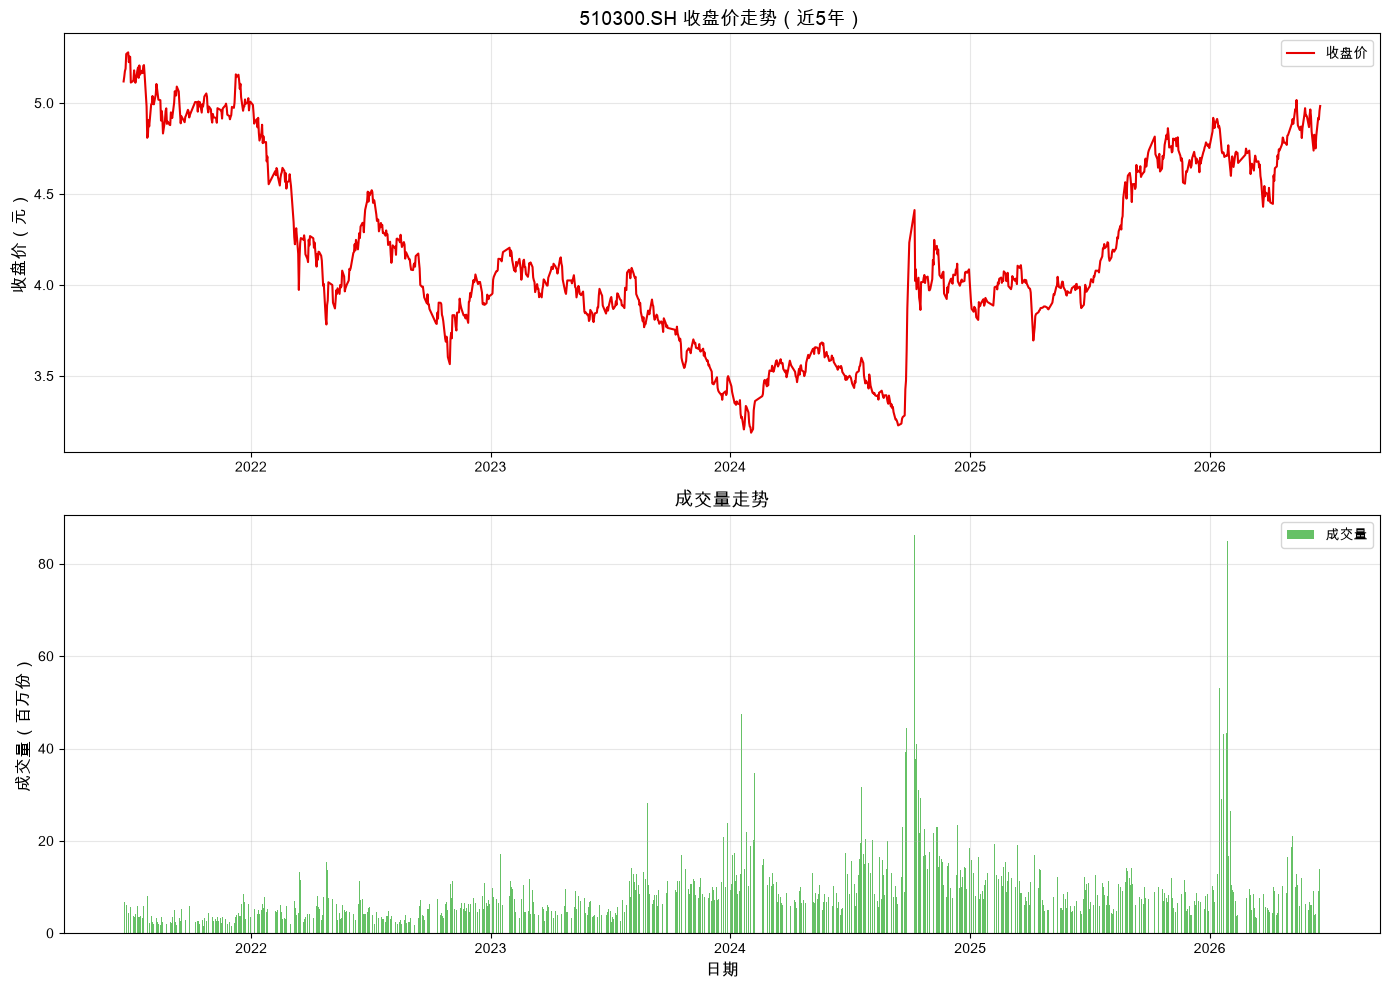

In [3]:
# 绘制收盘价和成交量基础图
import matplotlib.pyplot as plt
import matplotlib
import os

# 设置中文字体（macOS）
system = os.uname().sysname
if system == 'Darwin':
    matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'STHeiti', 'PingFang SC']
elif system == 'Windows':
    matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

# 抑制 matplotlib 字体警告
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 转换日期列为 datetime 类型
df['trade_date'] = pd.to_datetime(df['trade_date'])

# 创建图表
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# 上图：收盘价走势
ax1.plot(df['trade_date'], df['close'], color='#E60000', linewidth=1.5, label='收盘价')
ax1.set_title('510300.SH 收盘价走势（近5年）', fontsize=14, fontweight='bold')
ax1.set_ylabel('收盘价（元）', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# 下图：成交量走势
ax2.bar(df['trade_date'], df['vol'] / 1e6, color='#009900', alpha=0.6, label='成交量')
ax2.set_title('成交量走势', fontsize=14, fontweight='bold')
ax2.set_xlabel('日期', fontsize=12)
ax2.set_ylabel('成交量（百万份）', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()

# 保存图表
output_file = 'dashboard/price_volume_basic.png'
plt.savefig(output_file, dpi=150, bbox_inches='tight')
print(f'✓ 图表已保存至：{output_file}')

plt.show()

---  
**本章节完成**  
后续章节（数据质量检查、移动均线、收益率分析等）将在下一轮完成。  

⚠️ **当前限制**：  
- 前复权数据获取失败（Tushare 免费账号权限不足）  
- 数据质量检查留到下一轮  

---